In [2]:
!pip install scikit-learn

  Using cached scikit_learn-1.7.2-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (9.7 MB)
  Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
  Using cached scipy-1.15.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (37.7 MB)

[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [42]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import pandas as pd

In [43]:
clean_df = pd.read_csv("../data/clean_numeric_pattern.csv")

# Features
X = clean_df.drop(columns=["Target"])

# Target
y = clean_df["Target"]

In [44]:
# Standard scaler

standard_scaler = StandardScaler()

X_standard = standard_scaler.fit_transform(X)

In [45]:
X_standard_df = pd.DataFrame(
    X_standard,
    columns=X.columns,
    index=X.index
)

X_standard_df.to_csv("../data/standard_scaler.csv",index= False)
display(X_standard_df.head())

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10
0,0.319567,-0.668816,-1.048922,-0.679157,-1.044875,-0.792821,-0.645970,0.336214,2.471741,-0.949097
1,-1.026259,-0.234241,-0.749968,1.495702,-1.291910,2.482942,-1.722355,-1.408037,-1.849467,-1.024409
2,0.765673,0.192783,0.018079,-0.060236,-0.330657,-0.326842,-0.734955,0.990264,-0.548357,-0.575387
3,0.955946,0.186690,0.290092,-0.832897,0.697717,-0.370653,-1.305035,1.197892,-1.682771,1.422360
4,-1.938071,-1.591373,-0.624999,-1.142610,0.427419,-0.631060,-0.912502,1.406186,-1.859430,-0.960245


In [46]:
print("Means after StandardScaler:")
display(X_standard_df.mean())

print("\nStandard deviations after StandardScaler:")
display(X_standard_df.std())

Means after StandardScaler:


Feature_1    -1.037185e-16
Feature_2     1.648130e-16
Feature_3    -1.449217e-16
Feature_4    -1.094017e-16
Feature_5     1.989122e-17
Feature_6     3.267843e-17
Feature_7     2.220002e-16
Feature_8     1.877234e-16
Feature_9    -3.026307e-16
Feature_10    4.688644e-17
dtype: float64


Standard deviations after StandardScaler:


Feature_1     1.0001
Feature_2     1.0001
Feature_3     1.0001
Feature_4     1.0001
Feature_5     1.0001
Feature_6     1.0001
Feature_7     1.0001
Feature_8     1.0001
Feature_9     1.0001
Feature_10    1.0001
dtype: float64

In [14]:
# Min Max Scaler

minmax_scaler = MinMaxScaler()

X_minmax = minmax_scaler.fit_transform(X)

In [15]:
X_minmax_df = pd.DataFrame(
    X_minmax,
    columns=X.columns,
    index=X.index
)

X_minmax_df.to_csv("../data/minmax_scaler.csv",)

display(X_minmax_df.head())

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10
0,0.562739,0.306623,0.305761,0.305917,0.304013,0.092200,0.381263,0.604111,0.959750,0.227292
1,0.309029,0.431481,0.361091,0.941626,0.257217,1.000000,0.182366,0.098729,0.154763,0.205685
2,0.646837,0.554171,0.503242,0.486827,0.439308,0.221335,0.364820,0.793617,0.397144,0.334511
3,0.682707,0.552420,0.553586,0.260979,0.634114,0.209193,0.259479,0.853775,0.185816,0.907673
4,0.137138,0.041561,0.384221,0.170450,0.582911,0.137028,0.332013,0.914127,0.152907,0.224094


In [16]:
print("Minimum values:")
display(X_minmax_df.min())

print("\nMaximum values:")
display(X_minmax_df.max())

Minimum values:


Feature_1     0.0
Feature_2     0.0
Feature_3     0.0
Feature_4     0.0
Feature_5     0.0
Feature_6     0.0
Feature_7     0.0
Feature_8     0.0
Feature_9     0.0
Feature_10    0.0
dtype: float64


Maximum values:


Feature_1     1.0
Feature_2     1.0
Feature_3     1.0
Feature_4     1.0
Feature_5     1.0
Feature_6     1.0
Feature_7     1.0
Feature_8     1.0
Feature_9     1.0
Feature_10    1.0
dtype: float64

In [40]:
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

In [28]:
target_correlation = (
    clean_df
    .corr(numeric_only=True)["Target"]
    .drop("Target")
    .sort_values(
        key=abs,
        ascending=False
    )
)

display(target_correlation)

Feature_8     0.836083
Feature_1     0.298396
Feature_3     0.297745
Feature_4    -0.226144
Feature_2     0.198458
Feature_9     0.092048
Feature_5     0.050780
Feature_7     0.039045
Feature_6    -0.029968
Feature_10    0.005195
Name: Target, dtype: float64

In [29]:
correlation_threshold = 0.20

selected_by_correlation = (
    target_correlation[
        abs(target_correlation) >= correlation_threshold
    ]
    .index
    .tolist()
)

print("Features selected by correlation:")
print(selected_by_correlation)

Features selected by correlation:
['Feature_8', 'Feature_1', 'Feature_3', 'Feature_4']


In [30]:
variance_selector = VarianceThreshold(
    threshold=0.01
)

X_variance_array = variance_selector.fit_transform(X)

In [31]:
selected_by_variance = X.columns[
    variance_selector.get_support()
].tolist()

print("Features selected by Variance Threshold:")
print(selected_by_variance)

Features selected by Variance Threshold:
['Feature_1', 'Feature_2', 'Feature_3', 'Feature_4', 'Feature_5', 'Feature_6', 'Feature_7', 'Feature_8', 'Feature_9', 'Feature_10']


In [32]:
X_variance = pd.DataFrame(
    X_variance_array,
    columns=selected_by_variance,
    index=X.index
)

display(X_variance.head())

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10
0,54.570756,30.683384,73.857248,34.463610,-0.997091,5.708020,436.241956,6.438559,37.043679,-2.726610
1,34.400238,43.165021,81.274378,85.296915,-1.239023,61.888314,328.446838,1.893153,15.857470,-2.942670
2,61.256768,55.429814,100.329841,48.929734,-0.297629,13.699700,427.330514,8.142972,22.236607,-1.654494
3,64.108471,55.254794,107.078556,30.870235,0.709499,12.948322,370.239586,8.684036,16.674755,4.076734
4,20.734472,4.186153,84.374899,23.631261,0.444786,8.482274,409.549934,9.226837,15.808623,-2.758592


In [33]:
feature_comparison = pd.DataFrame({
    "Correlation": target_correlation,
    "Correlation Selected": [
        feature in selected_by_correlation
        for feature in target_correlation.index
    ],
    "Variance": X.var(),
    "Variance Selected": [
        feature in selected_by_variance
        for feature in X.columns
    ]
})

display(feature_comparison)

,Correlation,Correlation Selected,Variance,Variance Selected
Feature_1,0.298396,True,224.669256,True
Feature_10,0.005195,True,8.231920,True
Feature_2,0.198458,True,825.090221,True
Feature_3,0.297745,True,615.673175,True
Feature_4,-0.226144,False,546.413182,True
Feature_5,0.050780,False,0.959300,True
Feature_6,-0.029968,False,294.191344,True
Feature_7,0.039045,False,10031.112996,True
Feature_8,0.836083,False,6.792262,True
Feature_9,0.092048,False,24.042687,True


In [34]:
pca = PCA()

X_pca = pca.fit_transform(X_standard)

In [35]:
explained_variance = pca.explained_variance_ratio_

pca_table = pd.DataFrame({
    "Component": [
        f"PC{i + 1}"
        for i in range(len(explained_variance))
    ],
    "Explained Variance Ratio": explained_variance,
    "Cumulative Variance": np.cumsum(
        explained_variance
    )
})

display(pca_table)

,Component,Explained Variance Ratio,Cumulative Variance
0,PC1,0.107602,0.107602
1,PC2,0.105157,0.212759
2,PC3,0.104590,0.317349
3,PC4,0.102368,0.419717
4,PC5,0.100287,0.520004
5,PC6,0.099826,0.619830
6,PC7,0.096527,0.716356
7,PC8,0.095989,0.812346
8,PC9,0.094441,0.906787
9,PC10,0.093213,1.000000


In [36]:
pca_90 = PCA(
    n_components=0.90
)

X_pca_90 = pca_90.fit_transform(X_standard)

print(
    "Original number of features:",
    X.shape[1]
)

print(
    "Number of PCA components:",
    X_pca_90.shape[1]
)

print(
    "Explained variance:",
    pca_90.explained_variance_ratio_.sum()
)

Original number of features: 10
Number of PCA components: 9
Explained variance: 0.9067865920341251


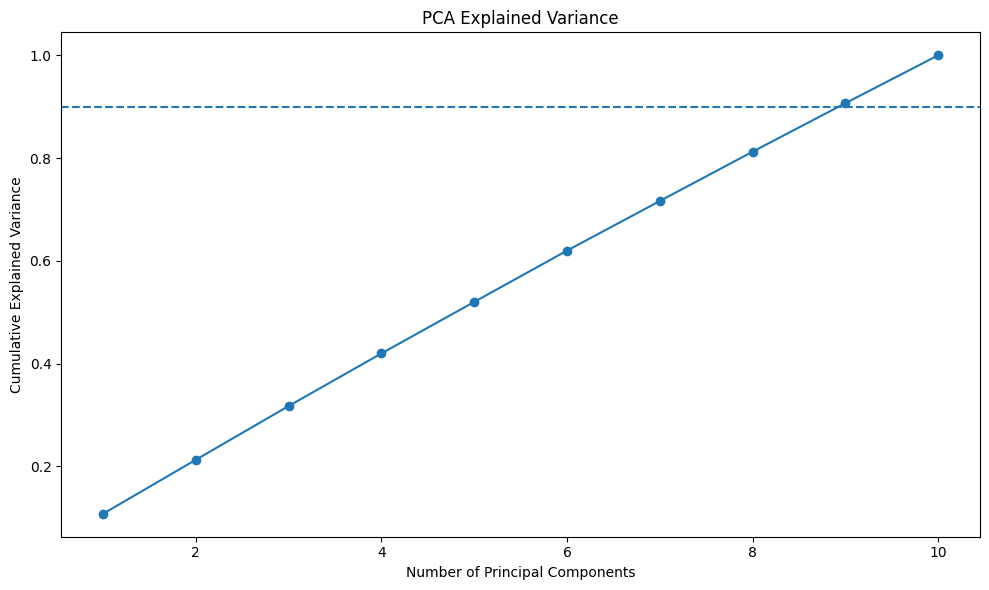

In [41]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(
        1,
        len(pca.explained_variance_ratio_) + 1
    ),
    np.cumsum(
        pca.explained_variance_ratio_
    ),
    marker="o"
)

plt.axhline(
    y=0.90,
    linestyle="--"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")

plt.tight_layout()
plt.show()